### Problem 1

Solve the boundary value problem:

$$
f''' - \left[(f')^2 - f f''\right] + 1 = 0,
$$

subject to the boundary conditions:

$$
f(0) = f'(0) = f'(1) = 0.
$$



In [16]:
import dolfin as df
import matplotlib.pyplot as plt


In [17]:
# Create a 1D mesh on the interval [0, 1]
mesh = df.UnitIntervalMesh(100)

# Define a second-order Lagrange (P2) element for each of the three unknowns: f, f', and f''
P2 = df.FiniteElement("Lagrange", mesh.ufl_cell(), 2)
ME = df.MixedElement([P2, P2, P2])  # mixed element
V = df.FunctionSpace(mesh, ME)      # Define function space for entire system


In [18]:
# Set up the trial and test functions
u = df.Function(V)       # The unknown function vector (our solution)
v = df.TestFunction(V)   # Test function for weak form
u0, u1, u2 = df.split(u) # Components: f, f', f''
v0, v1, v2 = df.split(v) # test functions


In [19]:
# Define the weak form (residual) of the 3rd-order ODE system, broken into 1st-order equations:
F = (
    (u0.dx(0) - u1) * v0 * df.dx +                      # u1 ≈ f'
    (u1.dx(0) - u2) * v1 * df.dx +                      #  u2 ≈ f''
    (u2.dx(0) - ((u1**2 - u0 * u2) - 1)) * v2 * df.dx   #  original ODE
)

# Compute the Jacobian automatically for the Newton solver
J = df.derivative(F, u)


In [20]:
# Define Dirichlet boundary conditions based on the problem:
# f(0) = 0, f'(0) = 0, f'(1) = 0
def left(x, on_boundary): return on_boundary and df.near(x[0], 0.0)
def right(x, on_boundary): return on_boundary and df.near(x[0], 1.0)

bcs = [
    df.DirichletBC(V.sub(0), df.Constant(0.0), left),   # f(0) = 0
    df.DirichletBC(V.sub(1), df.Constant(0.0), left),   # f'(0) = 0
    df.DirichletBC(V.sub(1), df.Constant(0.0), right)   # f'(1) = 0
]


In [21]:
# Provide an initial guess to help Newton solver converge
u_init = df.Expression(("0.1*x[0]", "0.1", "-1.0"), degree=2)  
u.interpolate(u_init)


In [22]:
# Solve the nonlinear system using Newton solver
print("Solving nonlinear problem...")
problem = df.NonlinearVariationalProblem(F, u, bcs, J)
solver = df.NonlinearVariationalSolver(problem)
solver.parameters["newton_solver"]["relative_tolerance"] = 1e-8
solver.parameters["newton_solver"]["maximum_iterations"] = 100
solver.parameters["newton_solver"]["report"] = True
solver.solve()


Solving nonlinear problem...


(3, True)

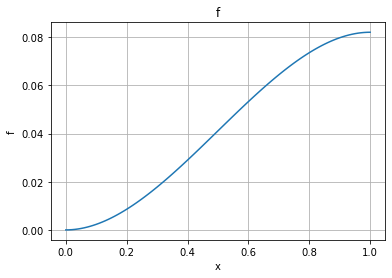

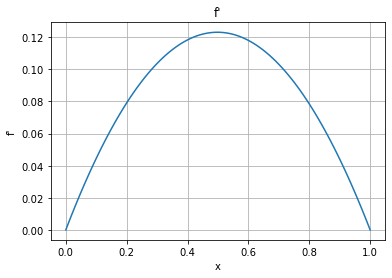

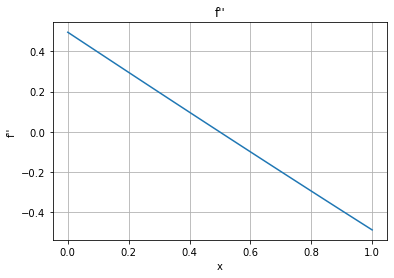

In [23]:
# Extract the solved components: f, f', and f''
u0_sol, u1_sol, u2_sol = u.split()

# Show plots inline
for sol, name in zip([u0_sol, u1_sol, u2_sol], ["f", "f'", "f''"]):
    plt.figure()
    df.plot(sol)
    plt.title(name)
    plt.xlabel("x")
    plt.ylabel(name)
    plt.grid(True)
    plt.show()


In [24]:
# Evaluate and print boundary values to ensure constraints were satisfied
print("Boundary condition checks:")
print("f(0)   =", u0_sol(0.0))   # Should be 0
print("f'(0)  =", u1_sol(0.0))   # Should be 0
print("f'(1)  =", u1_sol(1.0))   # Should be 0
print("f(1)   =", u0_sol(1.0))   # Not fixed but shown for interest


Boundary condition checks:
f(0)   = 0.0
f'(0)  = 0.0
f'(1)  = 0.0
f(1)   = 0.08204099667376932


In [25]:
# Now we check if the equation f''' = f'^2 - f*f'' - 1 holds numerically
V_scalar = df.FunctionSpace(mesh, "CG", 2)  
f3_approx = df.project(u2_sol.dx(0), V_scalar)  # Numerical f'''
rhs = df.project(u1_sol**2 - u0_sol*u2_sol - 1, V_scalar)  # RHS
residual = df.project(f3_approx - rhs, V_scalar)           # Difference = residual

# Compute L2 norm of the residual
residual_norm = df.assemble(residual**2 * df.dx)**0.5
print("L2 norm of ODE residual (should be close to 0):", residual_norm)

print("Solution and verification complete.")


L2 norm of ODE residual (should be close to 0): 1.7565015325262134e-14
Solution and verification complete.


## Problem 2

Consider the following modification of the heat equation in one spatial dimension:

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} + u(1 - u),
$$

with $ \alpha = \frac{1}{3} $, and boundary conditions:

$$
u(0, t) = u(2, t) = 0.
$$

Suppose the initial condition is:

$$
u(x, 0) = f(x),
$$

where $ f $ is given by the  piecewise cubic shown below:


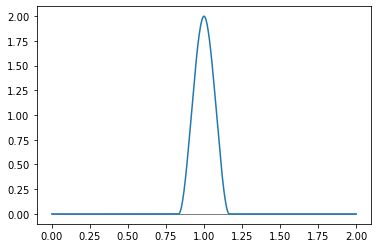

In [26]:
import math, numpy as np
from math import pi as π
import matplotlib.pyplot as plt
from scipy.interpolate import CubicHermiteSpline
xx = np.array([0,5/6,1,7/6,2])
yy = np.array([0, 0,2, 0,0])
ss = np.zeros_like(xx)
f = CubicHermiteSpline(xx,yy,ss)
x = np.linspace(0,2,1000)
plt.plot([0,2],[0,0],'k',lw=0.5)
plt.plot(x,f(x))

Estimate and plot the profile of $u(x,t)$ at time $t_{max}=20$.


#### Solve using Crank-Nicolson

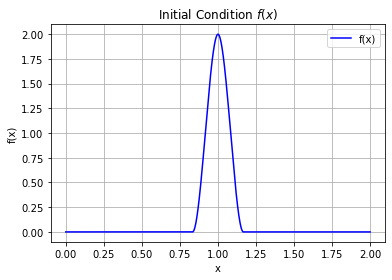

In [27]:
# Define the piecewise cubic Hermite spline
xx = np.array([0, 5/6, 1, 7/6, 2])
yy = np.array([0, 0, 2, 0, 0])
ss = np.zeros_like(xx)
f = CubicHermiteSpline(xx, yy, ss)

# Plot the initial condition
x_fine = np.linspace(0, 2, 1000)
plt.plot(x_fine, f(x_fine), label='f(x)', color='blue')
plt.title("Initial Condition $f(x)$")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()

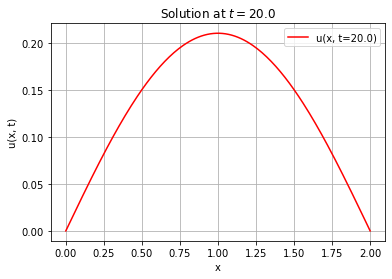

In [28]:
# Parameters
alpha = 1/3
L = 2.0
Nx = 200
dx = L / Nx
x = np.linspace(0, L, Nx + 1)

T = 20.0
dt = 0.01
Nt = int(T / dt)

# Initial condition sampled from the Hermite spline
u = f(x)
u[0] = u[-1] = 0  # Enforce boundary conditions

# Construct matrices for Crank-Nicolson
r = alpha * dt / (2 * dx**2)
main_diag = (1 + 2 * r) * np.ones(Nx - 1)
off_diag = -r * np.ones(Nx - 2)

A = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
B = np.diag(1 - 2 * r * np.ones(Nx - 1)) + np.diag(r * np.ones(Nx - 2), 1) + np.diag(r * np.ones(Nx - 2), -1)

# Time stepping
u_all = np.zeros((Nt + 1, Nx + 1))
u_all[0] = u.copy()

for n in range(1, Nt + 1):
    u_interior = u[1:-1]
    rhs = B @ u_interior + dt * u_interior * (1 - u_interior)
    u_new = np.linalg.solve(A, rhs)
    u[1:-1] = u_new
    u[0] = u[-1] = 0  # Dirichlet BCs
    u_all[n] = u.copy()

plt.plot(x, u_all[-1], label=f'u(x, t={T})', color='red')
plt.title(f'Solution at $t = {T}$')
plt.xlabel('x')
plt.ylabel('u(x, t)')
plt.grid(True)
plt.legend()
plt.show()
# no closed form soluton so we plot the graph at t_max=20

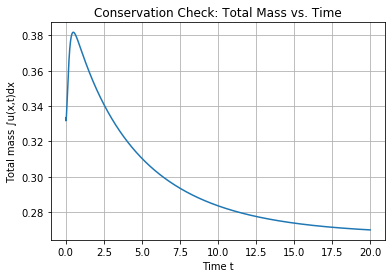

In [29]:
# "check" solution by plotting mass over time

mass = np.trapz(u_all, x, axis=1)

plt.plot(np.linspace(0, T, Nt+1), mass)
plt.xlabel("Time t")
plt.ylabel("Total mass ∫u(x,t)dx")
plt.title("Conservation Check: Total Mass vs. Time")
plt.grid(True)
plt.show()




The plot shows total mass $ \int_0^2 u(x,t)\,dx $ over time. There's an initial spike due to the reaction term $ u(1 - u) $ which is positive when $ 0 < u < 1 $ causing rapid growth from the initial data. This is followed by a smooth decay as diffusion dominates and the solution spreads toward the zero boundary conditions. Lack of oscillations or divergence confirms numerical stability and physically consistent behavior.
